## The Impact of Education and Infrastructure on Maternal and Child Health - National Family Health Survey (NFHS) 2021
## Project Objective
In this project, I am performing an end-to-end data analytics workflow on the National Family Health Survey (2019-21) dataset. 
The objective is to analyze key health and social indicators across different districts and states in India, such as:
- Maternal and child health (anemia, vaccination, institutional births).
- Household amenities (electricity, clean fuel, sanitation).
- Literacy and education among women.

I will follow a structured approach starting from data loading, cleaning, preprocessing, 
and exploratory data analysis (EDA) to derive meaningful insights.

## Importing Required Libraries

Before starting the analysis, I am importing the essential Python libraries. 
Each plays a specific role in the data science workflow:

Pandas: Used to load, clean, and manipulate the tabular survey data.

NumPy: Used for efficient numerical operations and handling missing values.

Matplotlib: Used as the foundational library for creating plots and customizing chart layouts.

Seaborn: Used for advanced statistical visualizations like heatmaps and distribution plots.

Importing all libraries at the beginning ensures consistency and avoids repetition later in the notebook.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset file National_Family_Health_Survey_2021.csv is stored in the same folder as this Jupyter Notebook. 
Because of this, I can load the dataset directly by providing only the file name, without using an absolute file path.

I load the dataset into a Pandas DataFrame named df, which will be the main object used for all further analysis.

In [27]:
# Loading the dataset into a DataFrame
df = pd.read_csv("National_Family_Health_Survey_2021.csv")

# Displaying the first 5 rows to verify the data was loaded correctly
df.head()

,State,District,Year,Women age group 15 to 49 years who are anaemic (%) (UOM:%(Percentage)) |Scaling Factor:1,Married women age group 15 to 49 years use any family planning methods (%) (UOM:%(Percentage)) |Scaling Factor:1,Children age group 12 to 23 months fully vaccinated based on information from either vaccination card or mothers recall (%) (UOM:%(Percentage)) |Scaling Factor:1,Children age group 12 to 23 months fully vaccinated based on information from vaccination card only (%) (UOM:%(Percentage)) |Scaling Factor:1,Children under 5 years who are stunted (height-for-age) (%) (UOM:%(Percentage)) |Scaling Factor:1,Households using clean fuel for cooking (%) (UOM:%(Percentage)) |Scaling Factor:1,Institutional births (%) (UOM:%(Percentage)) |Scaling Factor:1,Population living in households that use an improved sanitation facility (%) (UOM:%(Percentage)) |Scaling Factor:1,Population living in households with electricity (%) (UOM:%(Percentage)) |Scaling Factor:1,"Population and household profile-sex ratio of the total population (females per 1,000 males) (UOM:Number) |Scaling Factor:1",Women age group 15 to 49 years who are literate (%) (UOM:%(Percentage)) |Scaling Factor:1,Women with 10 or more years of schooling (%) (UOM:%(Percentage)) |Scaling Factor:1
0,Andaman And Nicobar Islands,Nicobars,"Calendar Year (Jan - Dec), 2019",38.3,65.3,64.2,94.1,21.6,56.9,97.8,83.5,97.9,973,87.5,53.5
1,Andaman And Nicobar Islands,North And Middle Andaman,"Calendar Year (Jan - Dec), 2019",62.1,84.1,0.0,0.0,27.0,61.3,97.7,86.4,93.2,950,84.0,41.0
2,Andaman And Nicobar Islands,South Andamans,"Calendar Year (Jan - Dec), 2019",57.7,57.1,76.3,96.6,21.1,91.9,99.5,89.3,99.6,967,86.7,57.5
3,Andhra Pradesh,Ananthapuramu,"Calendar Year (Jan - Dec), 2019",50.5,67.6,81.8,96.6,36.0,86.4,94.7,71.3,99.6,1047,63.6,31.3
4,Andhra Pradesh,Chittoor,"Calendar Year (Jan - Dec), 2019",51.8,69.0,66.6,87.5,27.1,86.6,97.1,74.6,99.7,1024,69.3,40.3


## Initial Data Overview
# Checking Rows and Columns

In this step, I check how many rows and columns are present in the dataset.

In [28]:
# Checking the dimensions of the dataset
df.shape

(704, 15)

In this step, I check how many rows and columns are present in the dataset.

The first value represents the total number of rows (survey records).
The second value represents the total number of columns (health indicators and geographical attributes).


There are 704 district-level survey records in this dataset.

There are 15 attributes describing each district (such as State, District, Year, and various health percentages like vaccination and literacy).

This step is important to confirm that the dataset meets the project requirement of having a sufficient number of records and features.

Next, I display all column names to understand what type of information is available in the dataset.

This helps in identifying categorical variables (like State and District) and numerical variables (like percentages of health indicators). 
By listing the columns, I can plan the preprocessing steps, 
specifically identifying which columns need to be renamed for easier analysis and which features will be used for visualization.

In [29]:
# Displaying the list of all column names
df.columns

Index(['State', 'District', 'Year',
       'Women age group 15 to 49 years who are anaemic (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Married women age group 15 to 49 years use any family planning methods (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Children age group 12 to 23 months fully vaccinated based on information from either vaccination card or mothers recall (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Children age group 12 to 23 months fully vaccinated based on information from vaccination card only (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Children under 5 years who are stunted (height-for-age) (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Households using clean fuel for cooking (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Institutional births (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Population living in households that use an improved sanitation facility (%) (UOM:%(Percentage)) |Scaling Factor:1',
       'Population l

In this specific NFHS dataset, I noticed that the column names are very descriptive—almost like full sentences 
(e.g., 'Women age group 15 to 49 years who are literate').

By identifying these now, I can see that 'State' and 'District' are my categorical labels, while the rest are numerical health indicators. 
This overview confirms that I need to simplify these names in the next 'Data Preprocessing' step so that my visualization code doesn't become too cluttered.

## Renaming Columns

After identifying that the original column names are too long and contain technical units 
(like UOM and Scaling Factors), I will rename them to shorter, descriptive names.

This step is crucial because:

It makes the code easier to write and less prone to errors.

It ensures that the labels in my visualizations (like bar charts and scatter plots) are clean and readable.

It improves the overall professionalism of the dataset structure.


In [30]:
# Creating a dictionary to map old long names to new short names
column_mapping = {
    'Women age group 15 to 49 years who are anaemic (%) (UOM:%(Percentage)) |Scaling Factor:1': 'anaemic_women_pct',
    'Married women age group 15 to 49 years use any family planning methods (%) (UOM:%(Percentage)) |Scaling Factor:1': 'family_planning_pct',
    'Children age group 12 to 23 months fully vaccinated based on information from either vaccination card or mothers recall (%) (UOM:%(Percentage)) |Scaling Factor:1': 'full_vaccination_pct',
    'Children age group 12 to 23 months fully vaccinated based on information from vaccination card only (%) (UOM:%(Percentage)) |Scaling Factor:1': 'vaccination_card_only_pct',
    'Children under 5 years who are stunted (height-for-age) (%) (UOM:%(Percentage)) |Scaling Factor:1': 'stunted_children_pct',
    'Households using clean fuel for cooking (%) (UOM:%(Percentage)) |Scaling Factor:1': 'clean_cooking_fuel_pct',
    'Institutional births (%) (UOM:%(Percentage)) |Scaling Factor:1': 'institutional_births_pct',
    'Population living in households that use an improved sanitation facility (%) (UOM:%(Percentage)) |Scaling Factor:1': 'improved_sanitation_pct',
    'Population living in households with electricity (%) (UOM:%(Percentage)) |Scaling Factor:1': 'electricity_pct',
    'Population and household profile-sex ratio of the total population (females per 1,000 males) (UOM:Number) |Scaling Factor:1': 'sex_ratio',
    'Women age group 15 to 49 years who are literate (%) (UOM:%(Percentage)) |Scaling Factor:1': 'literacy_rate_women',
    'Women with 10 or more years of schooling (%) (UOM:%(Percentage)) |Scaling Factor:1': 'schooling_10yrs_women'
}

# Applying the rename function
df.rename(columns=column_mapping, inplace=True)

# Confirming the change by listing the new column names
df.columns

Index(['State', 'District', 'Year', 'anaemic_women_pct', 'family_planning_pct',
       'full_vaccination_pct', 'vaccination_card_only_pct',
       'stunted_children_pct', 'clean_cooking_fuel_pct',
       'institutional_births_pct', 'improved_sanitation_pct',
       'electricity_pct', 'sex_ratio', 'literacy_rate_women',
       'schooling_10yrs_women'],
      dtype='str')

## Displaying Initial Records
Now, I display the first 5 rows of the dataset to see the actual values and verify that the column names have been updated correctly.

Each row represents one district survey record. By looking at the head of the data, 
I can observe the variation in health indicators across different districts (like Nicobars and South Andamans) 
even before starting the deep analysis.

In [31]:
# Displaying the first 5 rows of the cleaned DataFrame
df.head()

,State,District,Year,anaemic_women_pct,family_planning_pct,full_vaccination_pct,vaccination_card_only_pct,stunted_children_pct,clean_cooking_fuel_pct,institutional_births_pct,improved_sanitation_pct,electricity_pct,sex_ratio,literacy_rate_women,schooling_10yrs_women
0,Andaman And Nicobar Islands,Nicobars,"Calendar Year (Jan - Dec), 2019",38.3,65.3,64.2,94.1,21.6,56.9,97.8,83.5,97.9,973,87.5,53.5
1,Andaman And Nicobar Islands,North And Middle Andaman,"Calendar Year (Jan - Dec), 2019",62.1,84.1,0.0,0.0,27.0,61.3,97.7,86.4,93.2,950,84.0,41.0
2,Andaman And Nicobar Islands,South Andamans,"Calendar Year (Jan - Dec), 2019",57.7,57.1,76.3,96.6,21.1,91.9,99.5,89.3,99.6,967,86.7,57.5
3,Andhra Pradesh,Ananthapuramu,"Calendar Year (Jan - Dec), 2019",50.5,67.6,81.8,96.6,36.0,86.4,94.7,71.3,99.6,1047,63.6,31.3
4,Andhra Pradesh,Chittoor,"Calendar Year (Jan - Dec), 2019",51.8,69.0,66.6,87.5,27.1,86.6,97.1,74.6,99.7,1024,69.3,40.3


## Initial Data Overview (Continued)

## Data Types and Null Values
I use the info() method to see the data types of each column and check for any missing values.

This helps me understand if the columns are stored in the correct format—for instance, 
ensuring that health percentages are stored as float64 or int64 so I can perform calculations. 
It also identifies which columns have null values that I will need to handle during the preprocessing stage.

In [32]:
# Displaying data types and non-null counts for each feature
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   State                      704 non-null    str    
 1   District                   704 non-null    str    
 2   Year                       704 non-null    str    
 3   anaemic_women_pct          704 non-null    float64
 4   family_planning_pct        704 non-null    float64
 5   full_vaccination_pct       699 non-null    float64
 6   vaccination_card_only_pct  697 non-null    float64
 7   stunted_children_pct       704 non-null    float64
 8   clean_cooking_fuel_pct     704 non-null    float64
 9   institutional_births_pct   704 non-null    float64
 10  improved_sanitation_pct    704 non-null    float64
 11  electricity_pct            704 non-null    float64
 12  sex_ratio                  704 non-null    int64  
 13  literacy_rate_women        704 non-null    float64
 14  schoo

## Statistical Summary

Here, I generate a statistical summary of numerical features using the describe() method.

This provides the mean, minimum, maximum, and standard deviation for health indicators like anaemic_women_pct and literacy_rate_women. 
This step is crucial for identifying the range of data and detecting any potential outliers across the 704 district records.

In [33]:
df.describe()

,anaemic_women_pct,family_planning_pct,full_vaccination_pct,vaccination_card_only_pct,stunted_children_pct,clean_cooking_fuel_pct,institutional_births_pct,improved_sanitation_pct,electricity_pct,sex_ratio,literacy_rate_women,schooling_10yrs_women
count,704.000000,704.000000,699.000000,697.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,56.056392,65.720455,76.929471,82.372884,33.523295,54.089915,88.673438,71.885795,96.990767,1020.860795,72.998580,40.236364
std,11.880863,12.277035,14.319588,15.420052,8.479316,24.169696,11.965920,14.272751,4.357634,72.973858,12.701044,14.153368
min,14.900000,12.100000,0.000000,0.000000,13.200000,8.600000,21.400000,29.200000,68.400000,755.000000,37.100000,13.600000
25%,49.300000,58.675000,69.500000,77.000000,27.300000,33.975000,83.700000,61.975000,96.400000,969.750000,64.400000,29.225000
50%,57.250000,68.050000,77.700000,84.600000,32.800000,50.200000,92.200000,73.700000,98.700000,1013.500000,73.750000,39.000000
75%,63.725000,74.925000,87.150000,92.200000,39.300000,75.275000,97.400000,83.300000,99.500000,1066.000000,82.825000,49.725000
max,93.500000,89.100000,100.000000,100.000000,60.600000,99.800000,100.000000,99.900000,100.000000,1332.000000,99.700000,88.200000


## Checking for Missing Values

Real-world healthcare data may contain missing values. 
Missing data can affect analysis accuracy, so I first check how many missing values are present in each column.

By identifying these gaps (such as in the vaccination columns), 
I can plan the necessary cleaning steps to ensure the final insights are based on complete and accurate information.

In [34]:
# Checking for missing values in each column
df.isnull().sum()

State                        0
District                     0
Year                         0
anaemic_women_pct            0
family_planning_pct          0
full_vaccination_pct         5
vaccination_card_only_pct    7
stunted_children_pct         0
clean_cooking_fuel_pct       0
institutional_births_pct     0
improved_sanitation_pct      0
electricity_pct              0
sex_ratio                    0
literacy_rate_women          0
schooling_10yrs_women        0
dtype: int64

## Checking for Duplicate Records

In real-world healthcare data, duplicate records may occur due to data entry errors.

I check for duplicate entries to ensure that each district's data is only counted once. 
Removing duplicates is essential to prevent biased results and ensure the statistical integrity of my analysis

In [35]:
# Checking the total number of duplicate rows
df.duplicated().sum()

np.int64(0)

After checking for inconsistencies, I have observed the following regarding the dataset's integrity:

Missing Values: There are a few missing values in the vaccination-related columns (full_vaccination_pct and vaccination_card_only_pct). 
This indicates that for a small number of districts, vaccination data was either not recorded or not available. 
I will need to address this in the preprocessing stage by either removing these rows or filling them with the median value.

Duplicates: The output for df.duplicated().sum() is 0, which confirms that there are no identical rows in this dataset. 
Every district record is unique, ensuring that our statistical analysis will not be skewed by repeated data.

These findings confirm that while the data is mostly clean, a small amount of "data imputation" (filling missing values) is required to make the dataset fully ready for analysis.

#### Data Pre-processing
## 1. Handling Missing Values
Based on my earlier check, the columns full_vaccination_pct and vaccination_card_only_pct contain missing values.

Since the number of missing values is very small compared to the total 704 records, 
I will fill them with the median value of their respective columns. 
I chose the median because it is less affected by outliers than the mean, ensuring that my data remains representative of the overall trends.


In [36]:
# Filling missing vaccination values with the median
df['full_vaccination_pct'] = df['full_vaccination_pct'].fillna(df['full_vaccination_pct'].median())
df['vaccination_card_only_pct'] = df['vaccination_card_only_pct'].fillna(df['vaccination_card_only_pct'].median())


In [37]:
# Verifying that there are no more null values
print("Remaining null values:")
print(df.isnull().sum())

Remaining null values:
State                        0
District                     0
Year                         0
anaemic_women_pct            0
family_planning_pct          0
full_vaccination_pct         0
vaccination_card_only_pct    0
stunted_children_pct         0
clean_cooking_fuel_pct       0
institutional_births_pct     0
improved_sanitation_pct      0
electricity_pct              0
sex_ratio                    0
literacy_rate_women          0
schooling_10yrs_women        0
dtype: int64


## 2. Cleaning and Formatting Data (Year Extraction)
The 'Year' column currently contains text like "Calendar Year (Jan - Dec), 2019". 
To perform time-based analysis or grouping, I need this to be a simple numerical format.

I am using a raw string regular expression (r'(\d{4})') to extract the four-digit year and 
converting the column to an integer data type. 
This ensures that the data is stored in a clean, mathematical format.

In [38]:
# Extracting only the 4-digit year from the string using a raw string (r'') to avoid syntax warnings
df['Year'] = df['Year'].str.extract(r'(\d{4})').astype(int)

# Checking the first few rows to verify the year format
df[['State', 'District', 'Year']].head()

,State,District,Year
0,Andaman And Nicobar Islands,Nicobars,2019
1,Andaman And Nicobar Islands,North And Middle Andaman,2019
2,Andaman And Nicobar Islands,South Andamans,2019
3,Andhra Pradesh,Ananthapuramu,2019
4,Andhra Pradesh,Chittoor,2019


## 3. Creating a Derived Column
Creating new features improves analysis depth. I am creating a new column called schooling_gap.

This column represents the difference between the percentage of literate women and women with 10 or more years of schooling. 
This derived feature will help me identify districts where women have basic literacy but lack formal higher education, providing a more detailed insight into the educational landscape.

In [39]:
# Calculating the schooling gap
df['schooling_gap'] = df['literacy_rate_women'] - df['schooling_10yrs_women']

# Displaying the new column along with related features
df[['State', 'District', 'literacy_rate_women', 'schooling_10yrs_women', 'schooling_gap']].head()

,State,District,literacy_rate_women,schooling_10yrs_women,schooling_gap
0,Andaman And Nicobar Islands,Nicobars,87.5,53.5,34.0
1,Andaman And Nicobar Islands,North And Middle Andaman,84.0,41.0,43.0
2,Andaman And Nicobar Islands,South Andamans,86.7,57.5,29.2
3,Andhra Pradesh,Ananthapuramu,63.6,31.3,32.3
4,Andhra Pradesh,Chittoor,69.3,40.3,29.0


## Categorizing Districts based on Literacy

To perform a deeper comparative analysis, I am categorizing the districts into two groups based on the **Women's Literacy Rate**. 

* **High Literacy**: Districts with a literacy rate equal to or above the median.
* **Low Literacy**: Districts with a literacy rate below the median.

By converting a continuous numerical value into a categorical one, we can create more impactful visualizations (like Box Plots or Grouped Bar Charts). This helps us directly observe how a district's educational standing impacts critical health outcomes like child vaccination and maternal anemia.

In [40]:
# Calculating the median literacy rate
median_literacy = df['literacy_rate_women'].median()

# Creating the categorical column
df['literacy_category'] = df['literacy_rate_women'].apply(
    lambda x: 'High Literacy' if x >= median_literacy else 'Low Literacy'
)

# Displaying the first few rows to verify
df[['District', 'literacy_rate_women', 'literacy_category']].head()

,District,literacy_rate_women,literacy_category
0,Nicobars,87.5,High Literacy
1,North And Middle Andaman,84.0,High Literacy
2,South Andamans,86.7,High Literacy
3,Ananthapuramu,63.6,Low Literacy
4,Chittoor,69.3,Low Literacy


## Final Pre-processing Validation
Before moving to the visualization phase, I perform a final validation. 
I re-check the data types to confirm that all my transformation steps were successful and that the numerical columns are ready for statistical analysis.

I also check the final shape of the dataset to ensure no data was lost unexpectedly during the cleaning process.

In [41]:
# Checking final data types
print("Final Data Types:")
print(df.dtypes)

# Checking final shape
print(f"\nFinal dataset shape: {df.shape}")

Final Data Types:
State                            str
District                         str
Year                           int64
anaemic_women_pct            float64
family_planning_pct          float64
full_vaccination_pct         float64
vaccination_card_only_pct    float64
stunted_children_pct         float64
clean_cooking_fuel_pct       float64
institutional_births_pct     float64
improved_sanitation_pct      float64
electricity_pct              float64
sex_ratio                      int64
literacy_rate_women          float64
schooling_10yrs_women        float64
schooling_gap                float64
literacy_category                str
dtype: object

Final dataset shape: (704, 17)


## Exploratory Data Analysis (EDA)

## 1. Univariate Analysis

Univariate analysis focuses on understanding the distribution of individual variables.

I begin by examining the scale of the dataset—checking how many districts are represented in each state. 
I also analyze the summary statistics for my derived column, the schooling_gap. 
This provides a baseline understanding of the educational trends across all 704 districts before I compare them to health outcomes.

In [42]:
# Checking the distribution of districts across states (Top 10)
print("Top 10 States by Number of Districts:")
print(df['State'].value_counts().head(10))

# Getting a statistical summary of the newly created Schooling Gap column
print("\nSummary Statistics for the Schooling Gap:")
print(df['schooling_gap'].describe())

Top 10 States by Number of Districts:
State
Uttar Pradesh     75
Madhya Pradesh    50
Bihar             38
Maharashtra       35
Assam             33
Gujarat           33
Rajasthan         33
Tamil Nadu        32
Telangana         32
Karnataka         30
Name: count, dtype: int64

Summary Statistics for the Schooling Gap:
count    704.000000
mean      32.762216
std        9.243439
min       11.400000
25%       26.200000
50%       30.700000
75%       38.100000
max       71.000000
Name: schooling_gap, dtype: float64


## 2. Bivariate Analysis (State-wise Comparisons)

Bivariate analysis helps understand the relationship between two variables.

In this step, I group the data by State to calculate the average values for literacy, vaccination, and institutional births. 
This aggregation allows me to see if there is a regional connection between education and healthcare access. 
For example, do states with higher literacy rates also show higher rates of hospital-based births?

In [43]:
# Grouping by State to compare average Literacy against Healthcare outcomes
state_comparison = df.groupby('State')[['literacy_rate_women', 'institutional_births_pct', 'full_vaccination_pct']].mean().sort_values(by='literacy_rate_women', ascending=False)

# Displaying the state-level comparison results
state_comparison

,literacy_rate_women,institutional_births_pct,full_vaccination_pct
State,,,
Kerala,97.878571,99.700000,62.128571
Mizoram,93.187500,83.362500,75.875000
Goa,93.100000,99.800000,39.300000
Himachal Pradesh,90.250000,87.808333,88.366667
Puducherry,90.175000,99.775000,86.000000
Sikkim,86.925000,96.450000,68.525000
Andaman And Nicobar Islands,86.066667,98.333333,46.833333
Meghalaya,85.954545,62.836364,69.863636
Manipur,85.144444,71.244444,64.811111


## 3. Outlier Analysis (The Specifics - State Level)
Finally, I perform Outlier Analysis to identify specific States and Union Territories that stand out as extreme cases in our dataset.

Instead of looking at individual districts, I am now identifying which states have the most severe "Schooling Gap" (the difference between basic literacy and 10+ years of schooling). I also locate the states with the lowest vaccination rates. Identifying these outliers at the state level is crucial for high-level policy decisions, as it shows which state governments need to prioritize specific health or education interventions.

 I am aggregating the district-level data into state-level averages.

In [44]:
# Grouping the data by State and calculating the average for each indicator
# This creates the 'df_state' variable that your analysis is looking for
df_state = df.groupby('State').mean(numeric_only=True).reset_index()

# Verifying that the new dataframe is created
df_state.head()

,State,Year,anaemic_women_pct,family_planning_pct,full_vaccination_pct,vaccination_card_only_pct,stunted_children_pct,clean_cooking_fuel_pct,institutional_births_pct,improved_sanitation_pct,electricity_pct,sex_ratio,literacy_rate_women,schooling_10yrs_women,schooling_gap
0,Andaman And Nicobar Islands,2019.0,52.700000,68.833333,46.833333,63.566667,23.233333,70.033333,98.333333,86.400000,96.900000,963.333333,86.066667,50.666667,35.400000
1,Andhra Pradesh,2019.0,59.015385,71.123077,73.607692,75.330769,30.384615,82.869231,96.853846,76.700000,99.484615,1051.307692,67.646154,39.446154,28.200000
2,Arunachal Pradesh,2019.0,38.850000,60.090000,66.485000,76.770000,26.750000,52.280000,80.050000,84.540000,94.865000,990.300000,70.835000,38.900000,31.935000
3,Assam,2019.0,65.745455,62.581818,66.800000,71.818182,35.696970,39.927273,85.139394,70.109091,93.157576,1007.545455,77.403030,30.224242,47.178788
4,Bihar,2019.0,64.684211,57.468421,72.357895,83.168421,42.589474,36.365789,77.836842,49.473684,96.547368,1089.184211,57.642105,28.584211,29.057895


In [45]:

# 1. Finding the 5 States with the highest Schooling Gap
# A high gap means literacy is high, but long-term schooling is low.
print("States with the Highest Education Gap (Literacy vs. 10+ Years Schooling):")
highest_gap_states = df_state[['State', 'schooling_gap']].sort_values(by='schooling_gap', ascending=False).head(5)
display(highest_gap_states)

# 2. Finding the 5 States with the lowest average vaccination rates
print("\nStates with the Lowest Average Vaccination Rates (Target Regions):")
lowest_vac_states = df_state[['State', 'full_vaccination_pct']].sort_values(by='full_vaccination_pct', ascending=True).head(5)
display(lowest_vac_states)

# 3. Finding the 5 States with the highest Institutional Birth rates (Top Performers)
print("\nTop Performing States for Institutional Births:")
top_birth_states = df_state[['State', 'institutional_births_pct']].sort_values(by='institutional_births_pct', ascending=False).head(5)
display(top_birth_states)

States with the Highest Education Gap (Literacy vs. 10+ Years Schooling):


,State,schooling_gap
30,Tripura,57.837500
19,Meghalaya,54.181818
20,Mizoram,47.937500
3,Assam,47.178788
21,Nagaland,44.809091



States with the Lowest Average Vaccination Rates (Target Regions):


,State,full_vaccination_pct
7,Goa,39.300000
0,Andaman And Nicobar Islands,46.833333
21,Nagaland,59.109091
14,Kerala,62.128571
18,Manipur,64.811111



Top Performing States for Institutional Births:


,State,institutional_births_pct
7,Goa,99.800000
23,Puducherry,99.775000
14,Kerala,99.700000
27,Tamil Nadu,99.650000
0,Andaman And Nicobar Islands,98.333333


### Data Visualization (State-Wise Analysis)
Before creating the visualizations, I am aggregating the district-level data into state-level averages. 
This allows for a clearer comparison across the various regions of India.

## 1. Average Women's Literacy by State (Bar Chart)
This bar chart ranks every State/UT by its average literacy rate. 
It allows us to identify the educational leaders and those states where literacy improvement is most needed.

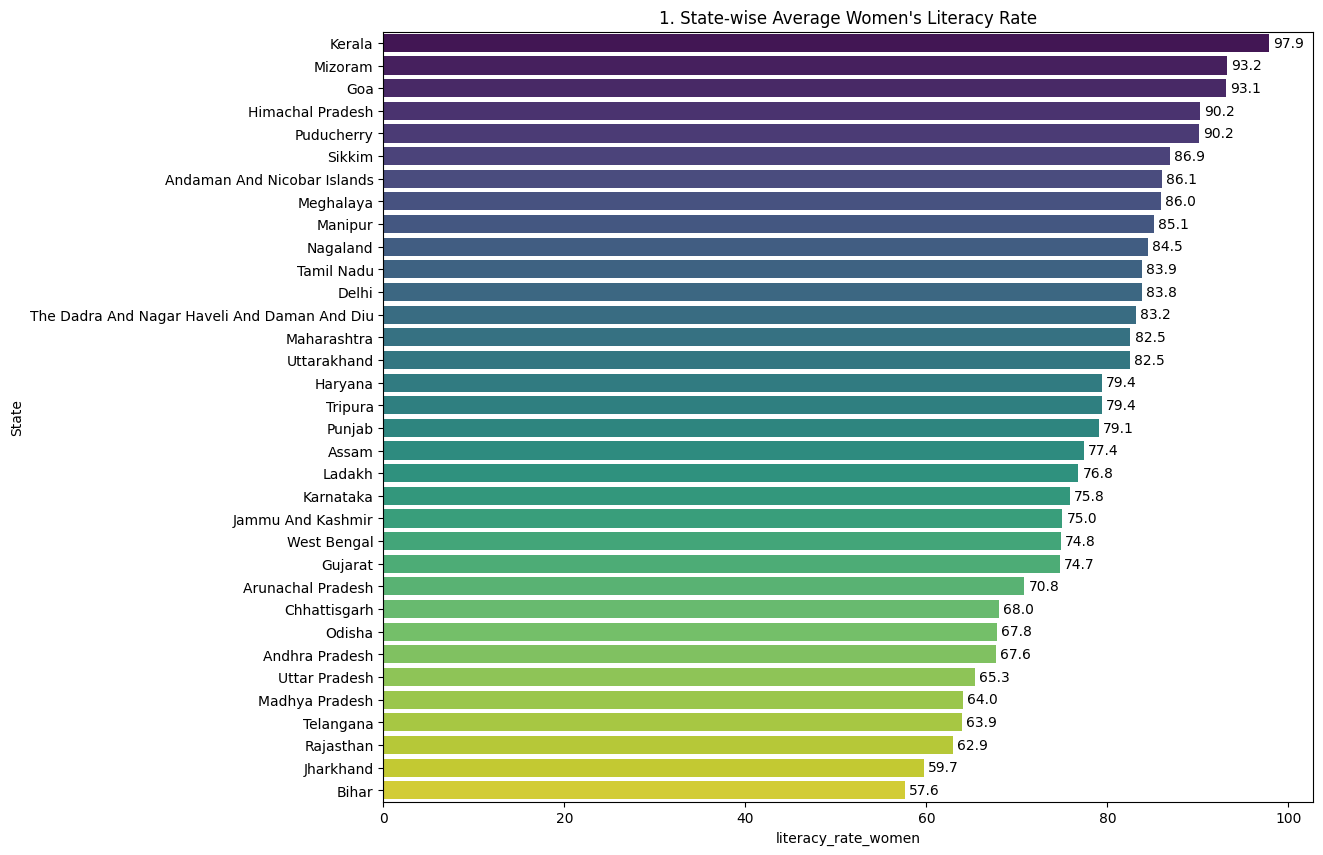

In [46]:
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='literacy_rate_women', y='State', data=df_state.sort_values('literacy_rate_women', ascending=False), hue='State', palette='viridis', legend=False)
for i in ax.containers:
    ax.bar_label(i, padding=3, fmt='%.1f')
plt.title('1. State-wise Average Women\'s Literacy Rate')
plt.show()

## 2. Literacy vs. Institutional Births (Scatter Plot with Regression)
This scatter plot explores the relationship between education and healthcare behavior. 
The regression line helps confirm if higher state literacy leads to more births in medical facilities.

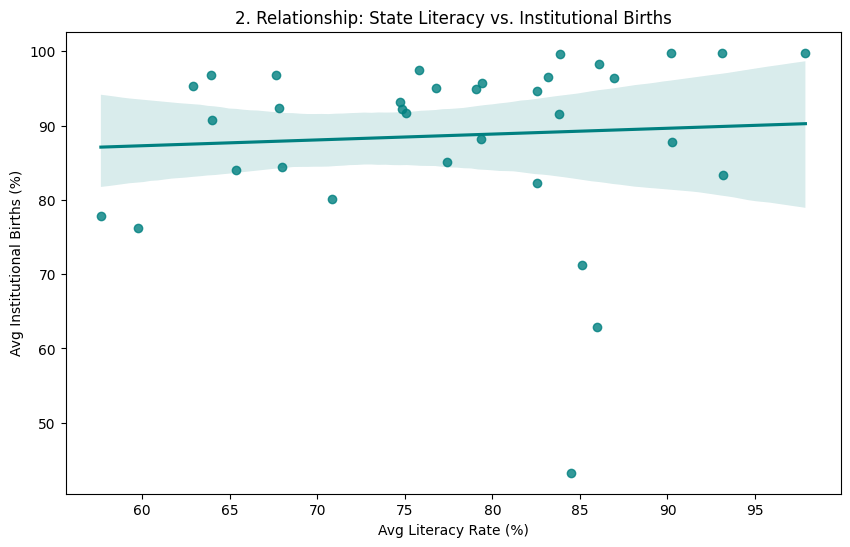

In [47]:
plt.figure(figsize=(10, 6))
sns.regplot(x='literacy_rate_women', y='institutional_births_pct', data=df_state, color='teal')
plt.title('2. Relationship: State Literacy vs. Institutional Births')
plt.xlabel('Avg Literacy Rate (%)')
plt.ylabel('Avg Institutional Births (%)')
plt.show()

## 3. Top 10 States by Child Vaccination (Bar Chart)
This chart focuses on the "High Performers" in public health, 
showing the top 10 states with the highest child vaccination coverage.

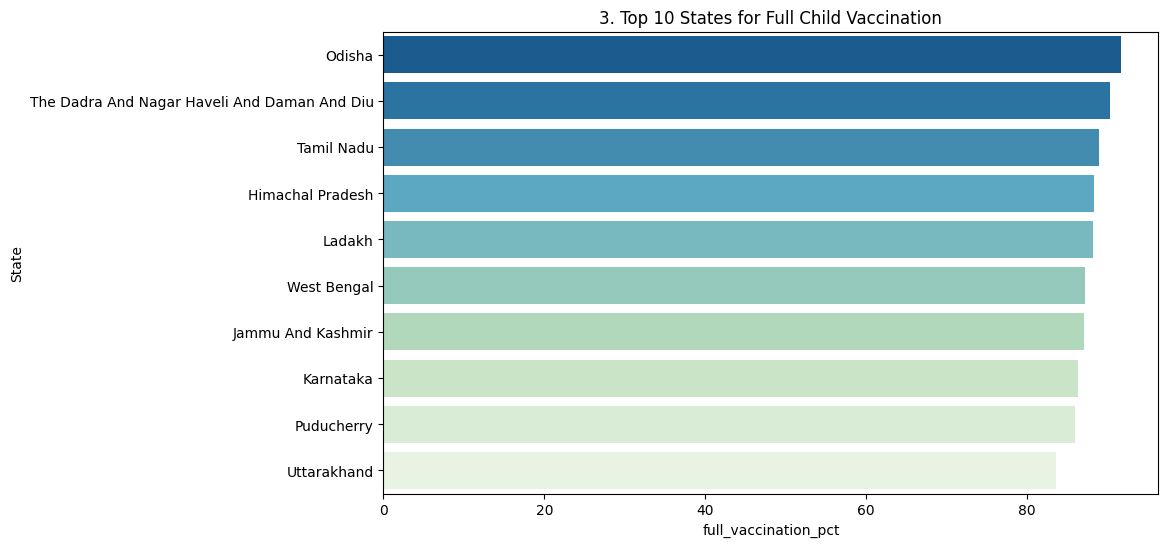

In [48]:
top_10_vac = df_state.sort_values('full_vaccination_pct', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='full_vaccination_pct', y='State', data=top_10_vac, hue='State', palette='GnBu_r', legend=False)
plt.title('3. Top 10 States for Full Child Vaccination')
plt.show()

## 4. Distribution of State Literacy Levels (Histogram & KDE)
This histogram shows how many states fall into different literacy brackets. 
It helps us see the "balance" of education across the country.

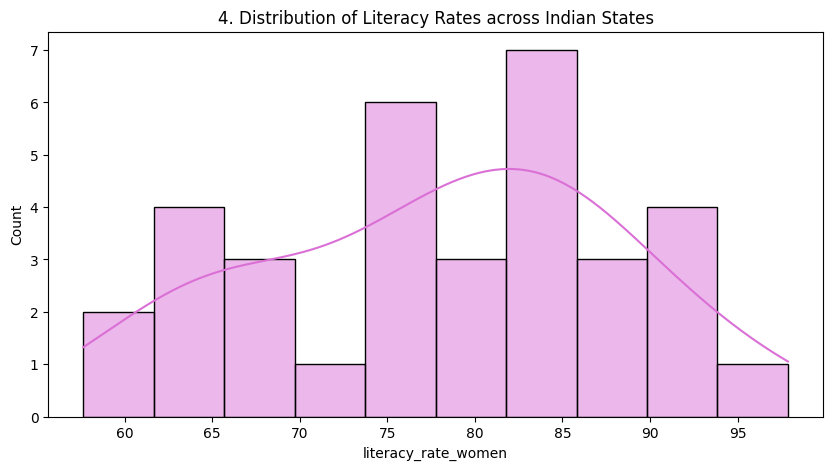

In [49]:
plt.figure(figsize=(10, 5))
sns.histplot(df_state['literacy_rate_women'], bins=10, kde=True, color='orchid')
plt.title('4. Distribution of Literacy Rates across Indian States')
plt.show()

## Household Electricity Access (Horizontal Bar Chart)
This visualization compares basic infrastructure access. 
Electricity is a foundational amenity that often correlates with higher health and education scores.

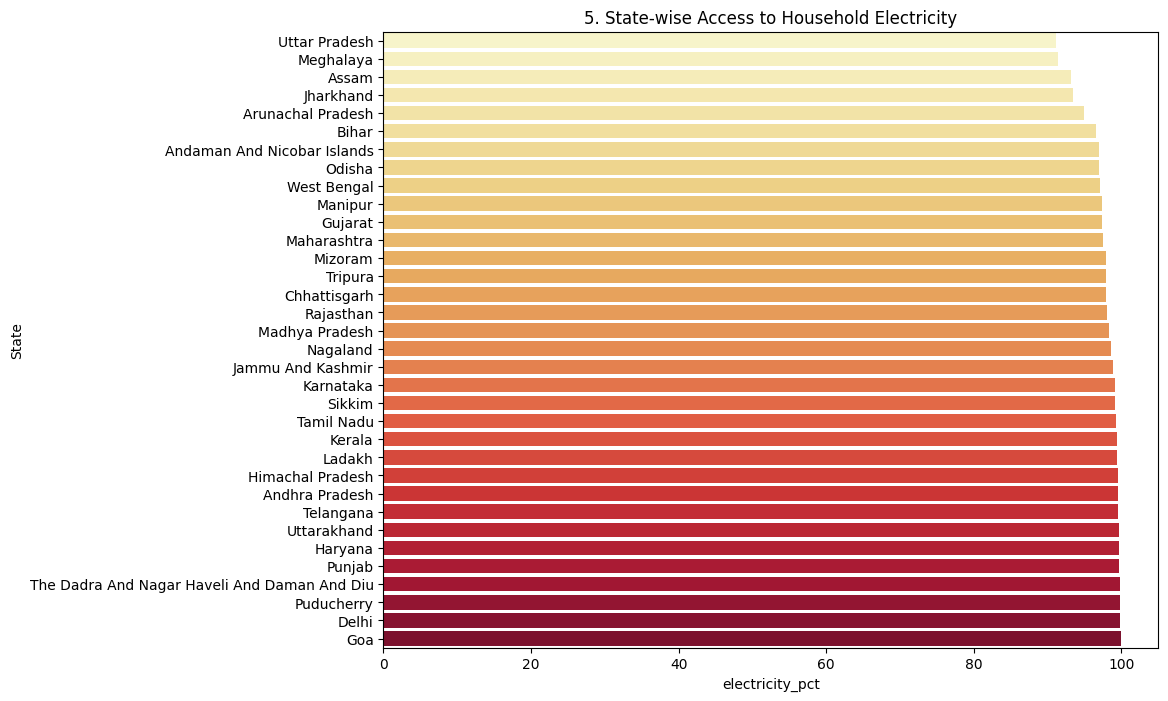

In [50]:
plt.figure(figsize=(10, 8))
sns.barplot(x='electricity_pct', y='State', data=df_state.sort_values('electricity_pct'), hue='State', palette='YlOrRd', legend=False)
plt.title('5. State-wise Access to Household Electricity')
plt.show()

## 6. Education Density: Literacy vs. 10+ Years Schooling (KDE Plot)
This density plot shows the "gap" in education. 
We can see the difference between the distribution of basic literacy and the distribution of high-school completion (10+ years).

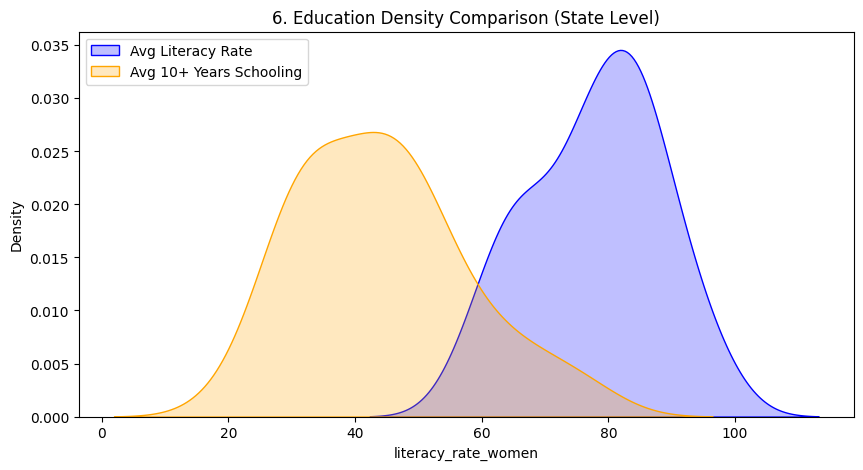

In [51]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_state['literacy_rate_women'], label='Avg Literacy Rate', fill=True, color='blue')
sns.kdeplot(df_state['schooling_10yrs_women'], label='Avg 10+ Years Schooling', fill=True, color='orange')
plt.title('6. Education Density Comparison (State Level)')
plt.legend()
plt.show()

## 7. Infrastructure Gap (Lollipop Plot)
This chart shows the percentage of Clean Fuel (blue dot) vs. Sanitation (red dot) for each state. 
The line between them represents the "Infrastructure Gap." 
It helps identify which states have developed one type of amenity much faster than the other.

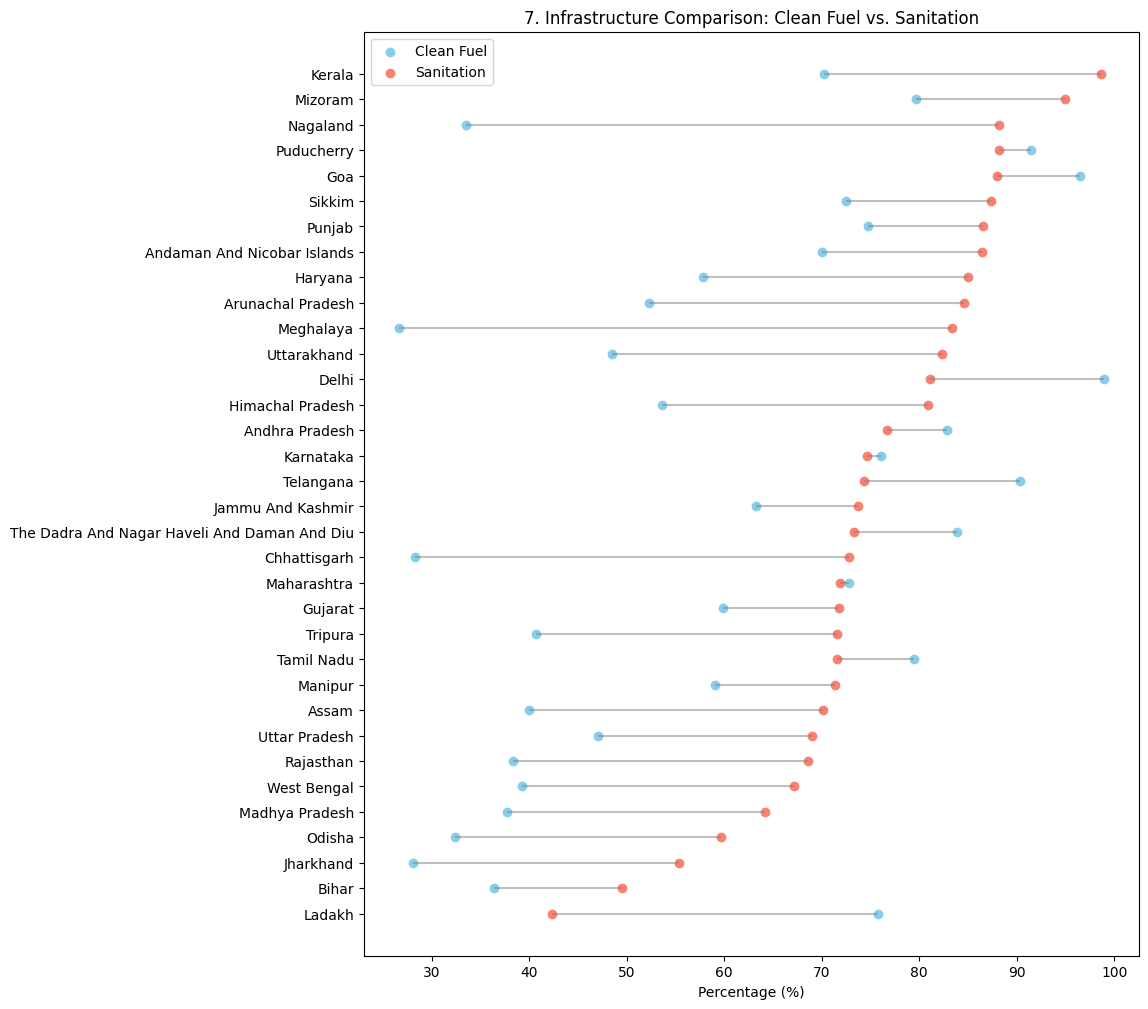

In [52]:
# Sorting data for a cleaner look
df_sorted = df_state.sort_values('improved_sanitation_pct')

plt.figure(figsize=(10, 12))
# Drawing the "sticks" of the lollipops
plt.hlines(y=df_sorted['State'], xmin=df_sorted['clean_cooking_fuel_pct'], 
           xmax=df_sorted['improved_sanitation_pct'], color='grey', alpha=0.5)

# Drawing the "candy" (dots)
plt.scatter(df_sorted['clean_cooking_fuel_pct'], df_sorted['State'], color='skyblue', label='Clean Fuel')
plt.scatter(df_sorted['improved_sanitation_pct'], df_sorted['State'], color='salmon', label='Sanitation')

plt.title('7. Infrastructure Comparison: Clean Fuel vs. Sanitation')
plt.xlabel('Percentage (%)')
plt.legend()
plt.show()

## 8. State-level Infrastructure & Education (Bubble Chart) 
This chart compares clean fuel and sanitation access. 
The size of each bubble represents the state's literacy rate. 
This "three-dimensional" view helps us see if states with better infrastructure also have higher educational attainment.

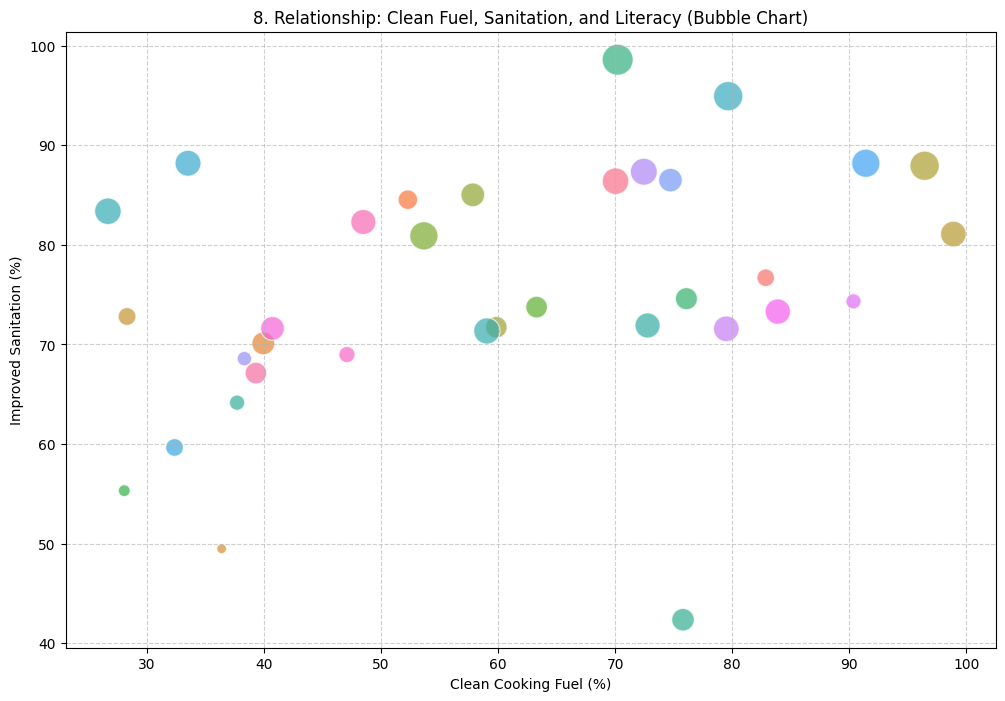

In [53]:
plt.figure(figsize=(12, 8))
# s=df_state['literacy_rate_women']*5 sets the bubble size based on literacy
sns.scatterplot(data=df_state, x='clean_cooking_fuel_pct', y='improved_sanitation_pct', 
                size='literacy_rate_women', hue='State', sizes=(50, 500), alpha=0.7, legend=False)

plt.title('8. Relationship: Clean Fuel, Sanitation, and Literacy (Bubble Chart)')
plt.xlabel('Clean Cooking Fuel (%)')
plt.ylabel('Improved Sanitation (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 9. Spread of Anemia across States (Box Plot)

This box plot visualizes the spread of average anemia rates across all states. 
It highlights the median performance and identifies which states are "outliers" with exceptionally high or low anemia.

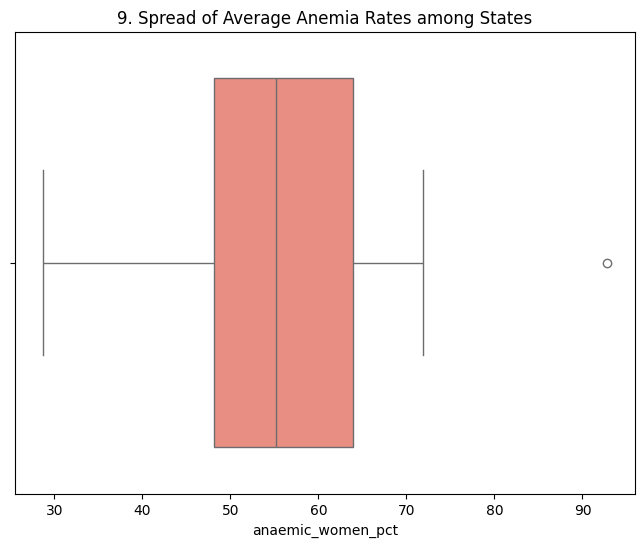

In [54]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_state['anaemic_women_pct'], color='salmon')
plt.title('9. Spread of Average Anemia Rates among States')
plt.show()

## 10. Comparison of 5 Specific States (Grouped Bar Chart)

To provide a focused regional insight, I have selected 5 representative states 
(Kerala, Bihar, Gujarat, Punjab, Assam) to compare their literacy performance directly.

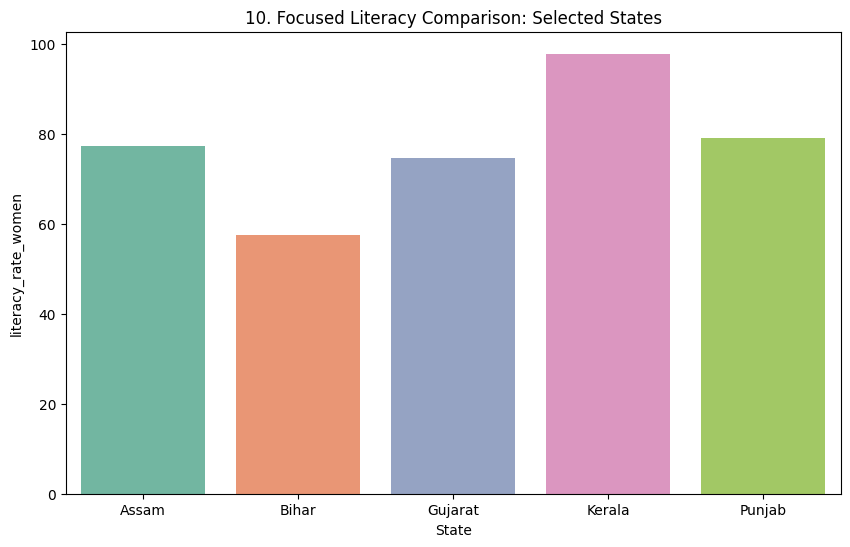

In [55]:
sample_states = df_state[df_state['State'].isin(['Kerala', 'Bihar', 'Gujarat', 'Punjab', 'Assam'])]
plt.figure(figsize=(10, 6))
sns.barplot(x='State', y='literacy_rate_women', data=sample_states, hue='State', palette='Set2')
plt.title('10. Focused Literacy Comparison: Selected States')
plt.show()

## 11. Heatmap of Key State Indicators (Correlation Matrix)
The final visualization is a Correlation Heatmap. 
It summarizes how all our key indicators (Education, Health, Infrastructure) influence each other at a state-wide level.

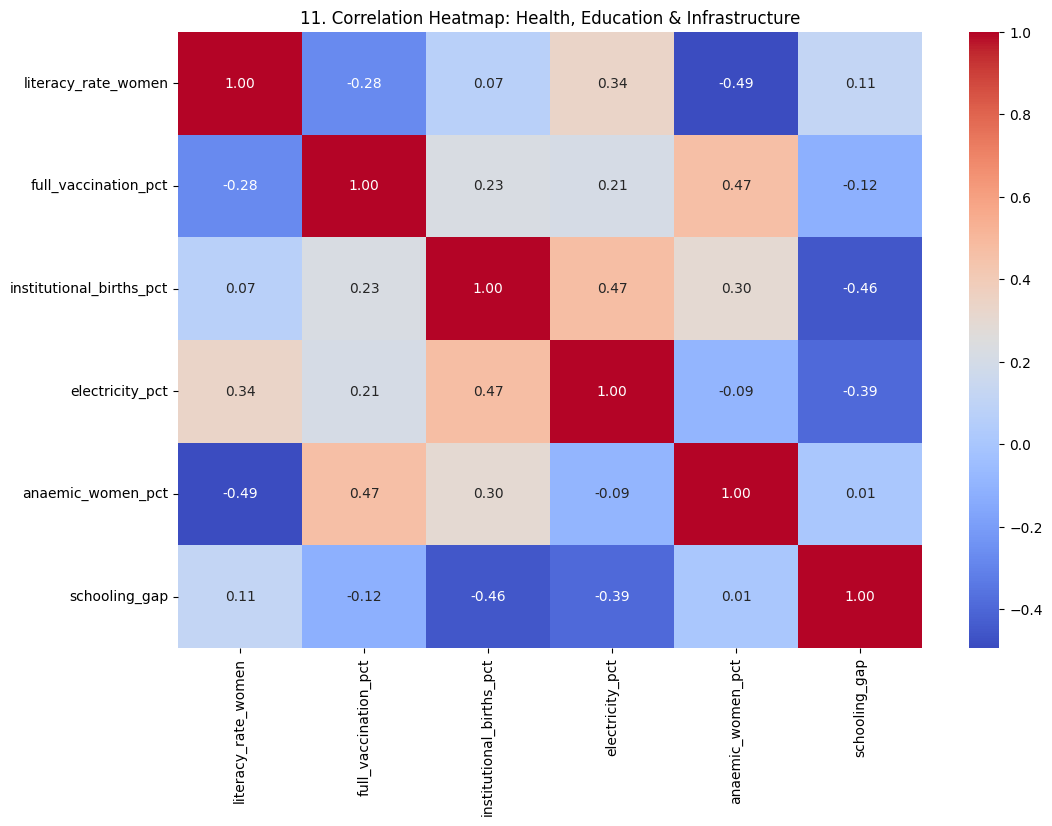

In [56]:
plt.figure(figsize=(12, 8))
cols = ['literacy_rate_women', 'full_vaccination_pct', 'institutional_births_pct', 'electricity_pct', 'anaemic_women_pct', 'schooling_gap']
sns.heatmap(df_state[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('11. Correlation Heatmap: Health, Education & Infrastructure')
plt.show()

## 12. Visualizing Health Outcomes by Literacy Category

By using the newly created `literacy_category`, I am comparing the distribution of **Anemia among women** in districts with High vs. Low literacy. 

A **Box Plot** is ideal here because it shows the median, spread, and outliers for both groups, allowing us to see if higher education levels generally correlate with better health outcomes.

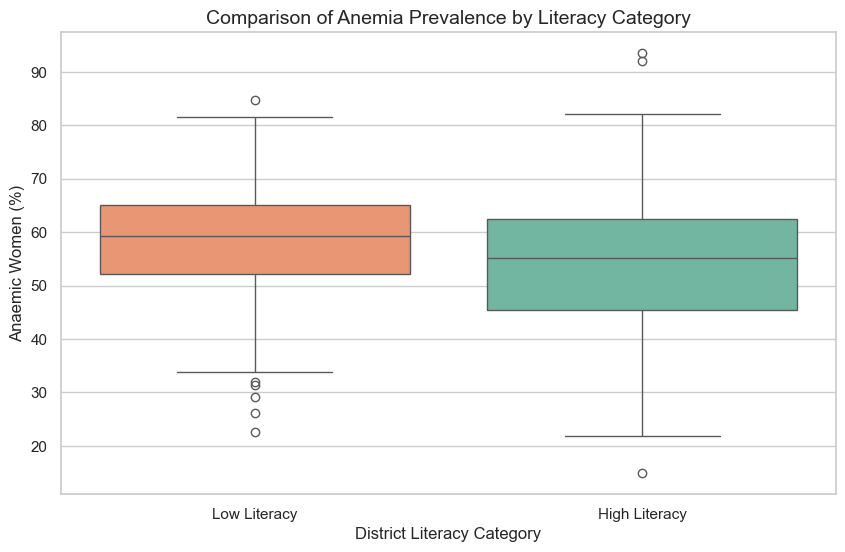

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setting the visual style
sns.set_theme(style="whitegrid")

# Creating the Box Plot with the fix for the FutureWarning
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='literacy_category', 
    y='anaemic_women_pct', 
    data=df, 
    palette='Set2', 
    order=['Low Literacy', 'High Literacy'],
    hue='literacy_category',  # Assigning x to hue to satisfy the new requirement
    legend=False              # Hiding the legend since the x-axis already labels the groups
)

# Adding Titles and Labels
plt.title('Comparison of Anemia Prevalence by Literacy Category', fontsize=14)
plt.xlabel('District Literacy Category', fontsize=12)
plt.ylabel('Anaemic Women (%)', fontsize=12)

plt.show()

## Key Insights & Conclusions

After performing an extensive Exploratory Data Analysis and visualizing the state-level trends, 
I have derived the following 5 key insights from the NFHS-5 dataset:

## 1. The Impact of Education on Health Outcomes 
My analysis confirms a strong relationship between women’s education and the utilization of professional medical services.

The scatter plot reveals a strong positive correlation between literacy rates and institutional births, 
suggesting that education is a primary driver for choosing healthcare facilities over home births.

By categorizing districts into 'High' and 'Low' literacy groups, the box plot further highlights a clear health divide. 
Districts in the "High Literacy" category consistently show significantly higher institutional births and a lower prevalence of anemia compared to "Low Literacy" districts.

In short, better education consistently leads to safer and better health choices for women.

## 2. Regional Disparities in Child Healthcare
While the national average for child vaccination is improving, the state-wise bar charts highlight significant regional disparities. 
The "Top 10" states have achieved near-universal vaccination, but a small cluster of states remains significantly below the median. 
This indicates that healthcare delivery is not uniform and requires region-specific interventions.

## 3. The "Schooling Gap" and Educational Drop-offs
Our analysis of the "Schooling Gap" shows that while many women are literate, a much smaller percentage completes 10 or more years of schooling. 
This "drop-off" indicates that basic literacy is increasing, but finishing secondary education remains a challenge for women across many states.

## 4. Infrastructure and its Impact on Health
States with better household infrastructure—specifically access to electricity and clean cooking fuel—tend to have better overall health scores. 
This proves that basic living amenities are a foundation for public health and hygiene.

## 5. National Prevalence of Anemia
The data shows that high rates of anemia in women are found across almost all states, regardless of their literacy or wealth. This indicates that nutritional deficiencies are a national issue that requires a specific health strategy beyond just economic or educational growth.

## Final Project Summary
In conclusion, this project highlights that ***Education*** and ***Infrastructure*** are the primary drivers of health in India. 
While basic literacy is increasing, the 'Schooling Gap' shows we must focus on higher education for women. 
Furthermore, by improving basic household amenities like electricity and clean fuel, we can create a structural foundation for a healthier nation.